# Zomato Restaurant Data — Exploratory Data Analysis

**Objective:** Explore restaurant-level data from Zomato (Bengaluru) to understand what factors —
online ordering, table booking, restaurant type, and cost — relate to customer ratings and popularity (votes).

**Dataset:** 148 restaurants, 7 columns: `name`, `online_order`, `book_table`, `rate`, `votes`,
`approx_cost(for two people)`, `listed_in(type)`.

**Key questions this notebook answers:**
1. Does accepting online orders or table bookings correlate with higher ratings?
2. Which restaurant type is most common, and how does it relate to online ordering?
3. What's the relationship between votes, rating, and cost?
4. Which restaurants are the most popular (by votes)?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

dataframe = pd.read_csv("Zomato-data-.csv")
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## 1. Data Cleaning

Three cleaning steps applied:
1. Convert `rate` from text (`4.1/5`) to a numeric value.
2. Rename `approx_cost(for two people)` → `cost_for_two` and `listed_in(type)` → `restaurant_type`
   for cleaner column names.
3. Check for and remove duplicate rows.

In [2]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

dataframe['rate'] = dataframe['rate'].apply(handleRate)

dataframe = dataframe.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'restaurant_type'
})

dataframe.head()

,name,online_order,book_table,rate,votes,cost_for_two,restaurant_type
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [3]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             148 non-null    str    
 1   online_order     148 non-null    str    
 2   book_table       148 non-null    str    
 3   rate             148 non-null    float64
 4   votes            148 non-null    int64  
 5   cost_for_two     148 non-null    int64  
 6   restaurant_type  148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


In [4]:
# Checking for missing/null values in each column
dataframe.isnull().sum()

name               0
online_order       0
book_table         0
rate               0
votes              0
cost_for_two       0
restaurant_type    0
dtype: int64

No missing values in any column.

In [5]:
# Checking for duplicate rows
duplicate_count = dataframe.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

dataframe = dataframe.drop_duplicates()
print(f"Shape after removing duplicates: {dataframe.shape}")

Duplicate rows found: 0
Shape after removing duplicates: (148, 7)


No duplicate rows either — the dataset was already clean going in. With cleaning
confirmed, we can move straight into exploration.

*(This same cleaned data is saved separately as `Zomato_cleaned.csv` for reuse in the
Power BI dashboard, so both the notebook and the dashboard are built from one
consistent, cleaned source.)*

## 2. Restaurant Type Distribution

How many restaurants fall into each `restaurant_type` category?

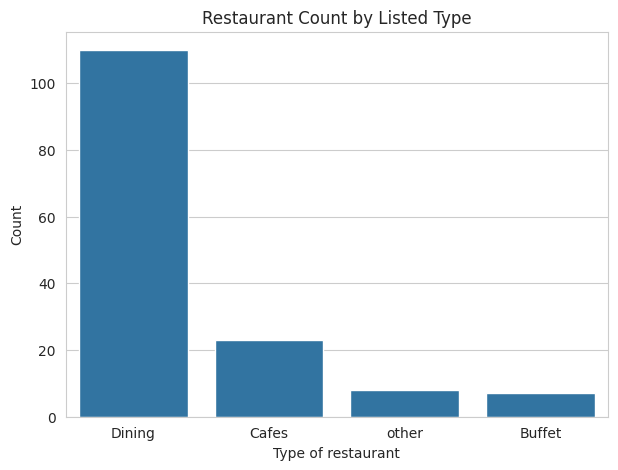

In [6]:
plt.figure(figsize=(7,5))
sns.countplot(x=dataframe['restaurant_type'], order=dataframe['restaurant_type'].value_counts().index)
plt.xlabel("Type of restaurant")
plt.ylabel("Count")
plt.title("Restaurant Count by Listed Type")
plt.show()

**Insight:** `Dining` dominates the dataset (110 of 148 restaurants), followed by
`Cafes` (23), `other` (8), and `Buffet` (7). Any conclusions about the smaller categories
should be treated cautiously given the low sample sizes.

## 3. Votes by Restaurant Type

Using a bar chart here (not a line chart) since `restaurant_type` is categorical —
there's no inherent order between the categories, so a line would imply a trend that doesn't exist.

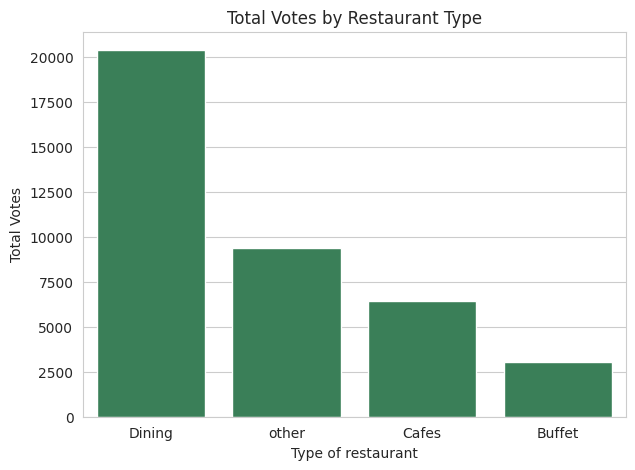

In [7]:
grouped_votes = dataframe.groupby('restaurant_type')['votes'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=grouped_votes.index, y=grouped_votes.values, color='seagreen')
plt.xlabel('Type of restaurant')
plt.ylabel('Total Votes')
plt.title('Total Votes by Restaurant Type')
plt.show()

**Insight:** `Dining` restaurants collect the most total votes by a wide margin —
consistent with them being the largest category, but it also suggests dining spots see
the most customer engagement overall.

## 4. Most Popular Restaurant (by Votes)

In [8]:
max_votes = dataframe['votes'].max()
top5 = dataframe.nlargest(5, 'votes')[['name', 'votes', 'rate']]
top5

,name,votes,rate
38,Empire Restaurant,4884,4.4
86,Meghana Foods,4401,4.4
7,Onesta,2556,4.6
44,Onesta,2556,4.6
65,Kabab Magic,1720,4.1


**Insight:** **Empire Restaurant** leads with 4,884 votes (rating 4.4), followed closely
by **Meghana Foods** (4,401 votes, 4.4) and **Onesta** (2,556 votes, 4.6 — appearing twice,
likely multiple branches). High vote counts here track with high ratings, not low ones.

## 5. Online Order Availability

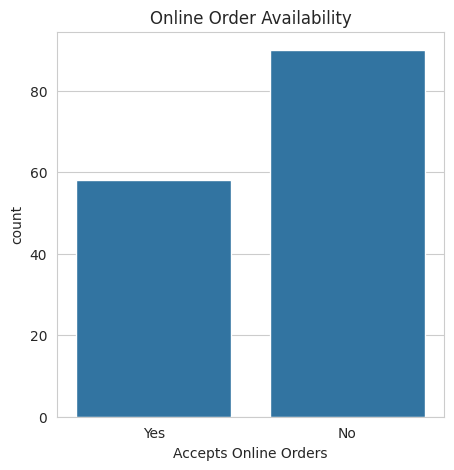

In [9]:
plt.figure(figsize=(5,5))
sns.countplot(x=dataframe['online_order'])
plt.title('Online Order Availability')
plt.xlabel('Accepts Online Orders')
plt.show()

**Insight:** 90 restaurants (61%) do **not** accept online orders, versus 58 (39%) that do —
so despite Zomato's online-ordering focus, the majority of listed restaurants in this sample
still rely on offline/dine-in orders.

## 6. Ratings Distribution

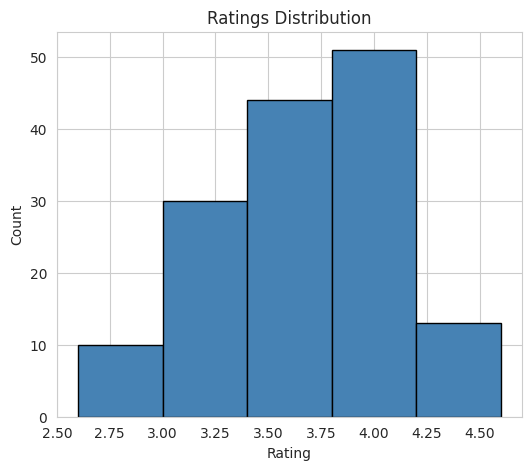

In [10]:
plt.figure(figsize=(6,5))
plt.hist(dataframe['rate'], bins=5, color='steelblue', edgecolor='black')
plt.title('Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

**Insight:** Ratings are roughly centered around 3.6–3.7 (mean ≈ 3.63, median 3.7), with
most restaurants falling between 3.3 and 3.9. Very few restaurants score below 3.0 or above 4.4.

## 7. Cost for Two Distribution

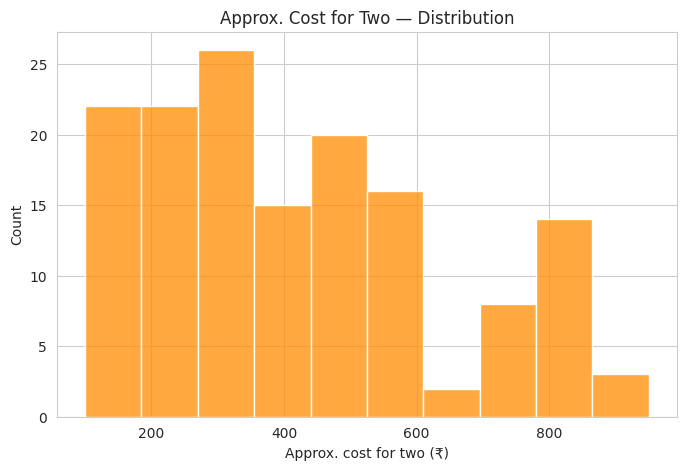

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(dataframe['cost_for_two'], bins=10, color='darkorange')
plt.title('Approx. Cost for Two — Distribution')
plt.xlabel('Approx. cost for two (₹)')
plt.ylabel('Count')
plt.show()

**Insight:** Costs range from ₹100 to ₹950, with a median of ₹400. Switched from a raw
`countplot` (which treats every unique price as its own category and gets unreadable) to a
`histplot` with bins, which is more appropriate for this near-continuous variable.

## 8. Rating vs. Online Order

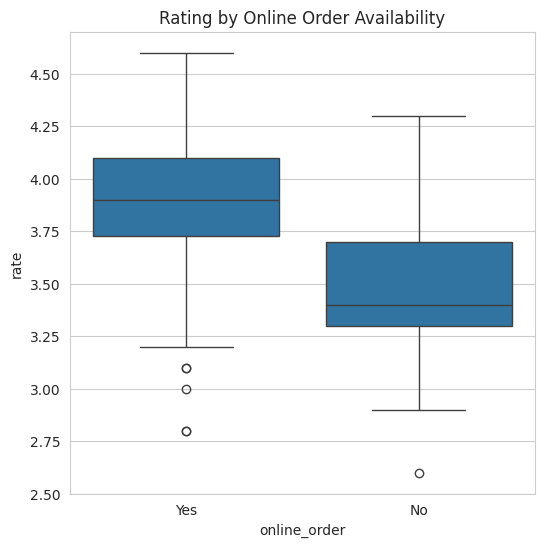

In [12]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order', y='rate', data=dataframe)
plt.title('Rating by Online Order Availability')
plt.show()

In [13]:
dataframe.groupby('online_order')['rate'].mean().round(2)

online_order
No     3.49
Yes    3.86
Name: rate, dtype: float64

**Insight:** Restaurants accepting online orders have a noticeably higher average rating
(**3.86**) than those that don't (**3.49**). This could reflect that better-run restaurants are
more likely to have invested in online ordering — or that online ordering itself drives more
(and more favorable) reviews. Correlation, not causation.

## 9. Rating vs. Table Booking

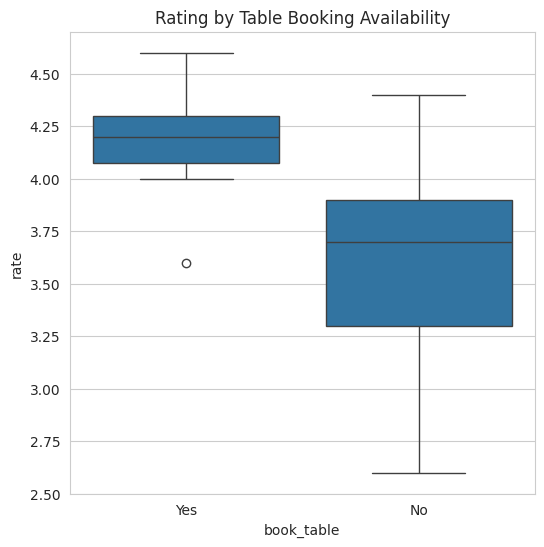

In [14]:
plt.figure(figsize=(6,6))
sns.boxplot(x='book_table', y='rate', data=dataframe)
plt.title('Rating by Table Booking Availability')
plt.show()

In [15]:
dataframe.groupby('book_table')['rate'].mean().round(2)

book_table
No     3.60
Yes    4.19
Name: rate, dtype: float64

**Insight:** The gap is even larger here — restaurants offering table booking average
**4.19**, versus **3.60** for those that don't. Table booking is often a feature of more
upscale, well-established restaurants, which likely explains the higher ratings.

## 10. Restaurant Type vs. Online Order (Heatmap)

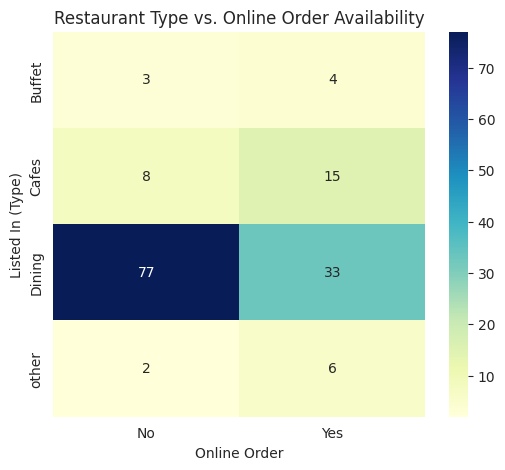

In [16]:
pivot_table = dataframe.pivot_table(index='restaurant_type', columns='online_order', aggfunc='size', fill_value=0)

plt.figure(figsize=(6,5))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Restaurant Type vs. Online Order Availability')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

**Insight:** `Dining` restaurants are fairly evenly split between accepting and not
accepting online orders (52 vs 58), while `Cafes` skew more toward online ordering (17 of 23).

## 11. Correlation Between Numeric Features

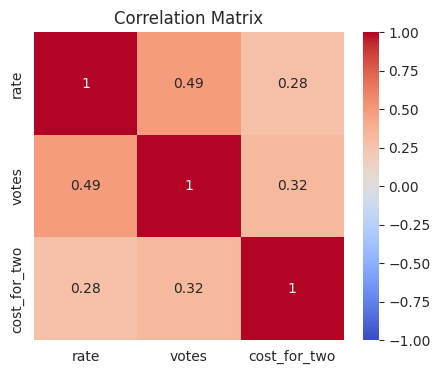

In [17]:
numeric_cols = ['rate', 'votes', 'cost_for_two']
corr = dataframe[numeric_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

**Insight:** `rate` and `votes` have a moderate positive correlation (**0.49**) — better-rated
restaurants tend to attract more votes/engagement. `Cost` correlates weakly with both `rate` (0.28)
and `votes` (0.32) — pricier restaurants trend slightly higher on both, but cost alone doesn't explain much.

## 12. Export Cleaned Data

Saving the cleaned dataframe for reuse in the Power BI dashboard, so both this
notebook and the dashboard are built from the same consistent, cleaned source.

In [18]:
dataframe['rating_band'] = pd.cut(dataframe['rate'], bins=[0,3,3.5,4,5], labels=['Below 3','3.0-3.5','3.5-4.0','4.0+'])
dataframe['cost_band'] = pd.cut(dataframe['cost_for_two'], bins=[0,300,500,700,1000], labels=['Under 300','300-500','500-700','700+'])

dataframe.to_csv('Zomato_cleaned.csv', index=False)
print("Saved Zomato_cleaned.csv —", dataframe.shape)

Saved Zomato_cleaned.csv — (148, 9)


## 13. Key Takeaways

- **No missing data** — the dataset required minimal cleaning beyond parsing the `rate` column.
- **Dining is the dominant category** (110/148 restaurants) and drives the most total votes.
- **Online ordering and table booking both associate with higher average ratings**
  (3.86 vs 3.49, and 4.19 vs 3.60 respectively) — likely a proxy for more established, better-run restaurants.
- **Votes correlate moderately with rating (r = 0.49)**, weakly with cost (r = 0.32) — popularity tracks
  quality more than price.
- **Empire Restaurant, Meghana Foods, and Onesta** are the standout restaurants by customer engagement (votes),
  all with ratings of 4.4+.

**Next steps:** This EDA sets up two follow-on projects:
1. A BI dashboard summarizing these KPIs (avg. rating by type, votes distribution, online-order impact).
2. A machine learning model predicting restaurant `rate` from the other features (online_order, book_table,
   votes, cost, type) — feasible given the moderate correlations found here.
